In [10]:
import random
import matplotlib.pyplot as plt
import numpy as np
import statistics
from collections import Counter

Modified BA algorithm

In [11]:
def barabasi_albert_graph(N, m0, m, n_power=1):
    if m > m0:
        raise ValueError("m must be <= m0 for a valid initial network")

    def erdos_renyi_graph(m0, p):
        adjacency_list = {i: set() for i in range(m0)}
        edge_created = 0
        for i in range(m0):
            for j in range(i + 1, m0):
                if random.random() < p:
                    adjacency_list[i].add(j)
                    adjacency_list[j].add(i)
                    edge_created = 1

        if edge_created == 0:
            adjacency_list[0].add(1)
            adjacency_list[1].add(0)

        return adjacency_list

    p = 0.5
    adjacency_list = erdos_renyi_graph(m0, p)

    for new_node in range(m0, N):
        degrees = {node: len(neighbors) ** n_power for node, neighbors in adjacency_list.items()}
        total_degree = sum(degrees.values())
        nodes = list(degrees.keys())
        probabilities = [degrees[node] / total_degree for node in nodes]
        targets = set(random.choices(nodes, weights=probabilities, k=m))
        adjacency_list[new_node] = targets
        for target in targets:
            adjacency_list[target].add(new_node)

    return adjacency_list

Compute and compare topological features of network created with modified BA algorithm

In [12]:
def compute_average_clustering_coefficient(graph):
    clustering_coeffs = []
    for node in graph:
        neighbors = graph[node]
        if len(neighbors) < 2:
            clustering_coeffs.append(0)
            continue
        links = sum(1 for neighbor in neighbors for other in neighbors if other in graph[neighbor]) / 2
        clustering_coeffs.append(2 * links / (len(neighbors) * (len(neighbors) - 1)))
    return sum(clustering_coeffs) / len(clustering_coeffs)

def compute_characteristic_path_length(graph):
    def bfs_shortest_path(start):
        queue = [(start, 0)]
        visited = {start}
        path_lengths = []
        while queue:
            node, length = queue.pop(0)
            path_lengths.append(length)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append((neighbor, length + 1))
        return path_lengths

    all_lengths = []
    for node in graph:
        all_lengths.extend(bfs_shortest_path(node))
    return sum(all_lengths) / len(all_lengths)

def compute_degree_distribution(graph):
    degrees = [len(neighbors) for neighbors in graph.values()]
    return Counter(degrees)

In [ ]:
num_networks = 100
N, m0, m = 200, 5, 2
n_power = 2

BA:
 Feature                         | (Mean - Std deviation, Mean + Std deviation) 
---------------------------------|----------------------------------------------
 Average clustering coefficient  | (0.0721 - 0.0217, 0.0721 + 0.0217) 
 Characteristic path length      | (3.3684 - 0.0796, 3.3684 + 0.0796) 

Mod_BA:
 Feature                         | (Mean - Std deviation, Mean + Std deviation) 
---------------------------------|----------------------------------------------
 Average clustering coefficient  | (0.2791 - 0.1458, 0.2791 + 0.1458) 
 Characteristic path length      | (2.0865 - 0.0863, 2.0865 + 0.0863) 



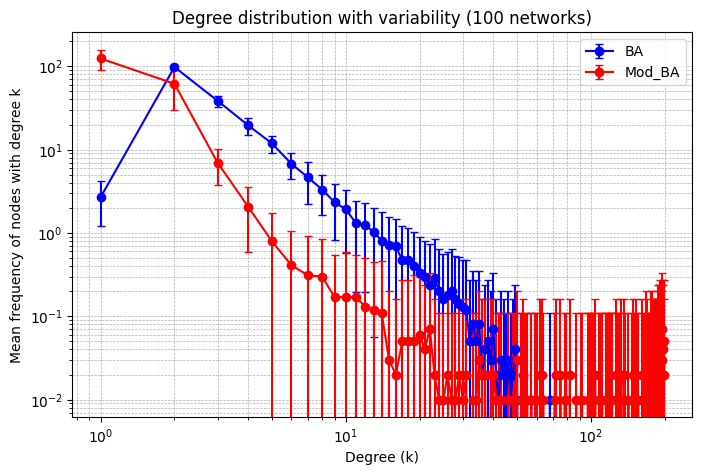

In [13]:
metrics = {"BA": {"clustering": [], "path_length": [], "degree_distributions": []},
           "Mod_BA": {"clustering": [], "path_length": [], "degree_distributions": []}}

for _ in range(num_networks):
    G_BA = barabasi_albert_graph(N, m0, m)
    G_ModBA = barabasi_albert_graph(N, m0, m, n_power=n_power)

    metrics["BA"]["clustering"].append(compute_average_clustering_coefficient(G_BA))
    metrics["BA"]["path_length"].append(compute_characteristic_path_length(G_BA))
    metrics["BA"]["degree_distributions"].append(compute_degree_distribution(G_BA))

    metrics["Mod_BA"]["clustering"].append(compute_average_clustering_coefficient(G_ModBA))
    metrics["Mod_BA"]["path_length"].append(compute_characteristic_path_length(G_ModBA))
    metrics["Mod_BA"]["degree_distributions"].append(compute_degree_distribution(G_ModBA))

for model in ["BA", "Mod_BA"]:
    mean_clustering = statistics.mean(metrics[model]["clustering"])
    std_clustering = statistics.stdev(metrics[model]["clustering"])
    mean_path_length = statistics.mean(metrics[model]["path_length"])
    std_path_length = statistics.stdev(metrics[model]["path_length"])

    print(f"{model}:")
    print(" Feature                         | (Mean - Std deviation, Mean + Std deviation) ")
    print("---------------------------------|----------------------------------------------")
    print(f" Average clustering coefficient  | ({mean_clustering:.4f} - {std_clustering:.4f}, {mean_clustering:.4f} + {std_clustering:.4f}) ")
    print(f" Characteristic path length      | ({mean_path_length:.4f} - {std_path_length:.4f}, {mean_path_length:.4f} + {std_path_length:.4f}) \n")

# Plot degree distributions
plt.figure(figsize=(8, 5))
for model, color in zip(["BA", "Mod_BA"], ['b', 'r']):
    combined_degree_dist = Counter()
    for dist in metrics[model]["degree_distributions"]:
        combined_degree_dist.update(dist)

    degree_vals = list(range(1, N))
    degree_means = []
    degree_stds = []

    for k in degree_vals:
        freqs = [dist.get(k, 0) for dist in metrics[model]["degree_distributions"]]
        if freqs:
            degree_means.append(statistics.mean(freqs))
            degree_stds.append(statistics.stdev(freqs) if len(freqs) > 1 else 0)
        else:
            degree_means.append(0)
            degree_stds.append(0)

    plt.errorbar(degree_vals, degree_means, yerr=degree_stds, fmt='o', linestyle='-', capsize=3, label=model, color=color)

plt.xlabel("Degree (k)")
plt.ylabel("Mean frequency of nodes with degree k")
plt.title("Degree distribution with variability (100 networks)")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

Create higher order variants and compare them in terms of topological features

In [ ]:
num_networks = 100
N, m0, m = 200, 5, 2
max_n_power = 5  # Maximum exponent for higher-order networks

Mod_BA (n=1):
 Feature                         | (Mean - Std deviation, Mean + Std deviation) 
---------------------------------|----------------------------------------------
 Average clustering coefficient  | (0.0767 - 0.0258, 0.0767 + 0.0258) |
 Characteristic path length      | (3.3733 - 0.0875, 3.3733 + 0.0875) |

Mod_BA (n=2):
 Feature                         | (Mean - Std deviation, Mean + Std deviation) 
---------------------------------|----------------------------------------------
 Average clustering coefficient  | (0.2463 - 0.1332, 0.2463 + 0.1332) |
 Characteristic path length      | (2.0852 - 0.0762, 2.0852 + 0.0762) |

Mod_BA (n=3):
 Feature                         | (Mean - Std deviation, Mean + Std deviation) 
---------------------------------|----------------------------------------------
 Average clustering coefficient  | (0.0675 - 0.0841, 0.0675 + 0.0841) |
 Characteristic path length      | (2.0053 - 0.0301, 2.0053 + 0.0301) |

Mod_BA (n=4):
 Feature               

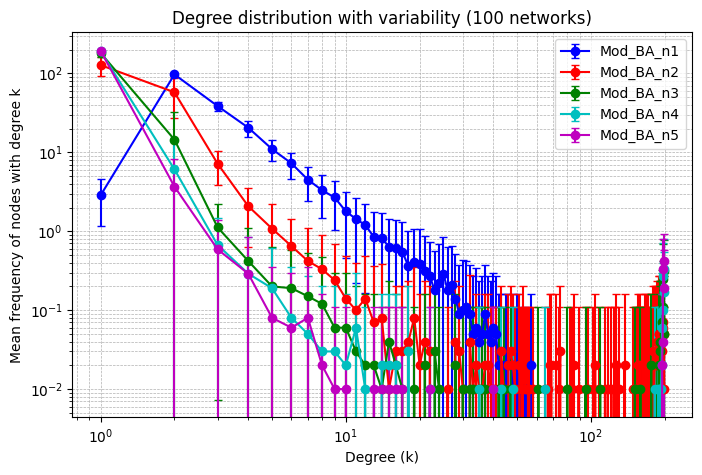

In [14]:
metrics = {}

for n_power in range(1, max_n_power + 1):
    metrics[f"Mod_BA_n{n_power}"] = {"clustering": [], "path_length": [], "degree_distributions": []}

    for _ in range(num_networks):
        G_ModBA = barabasi_albert_graph(N, m0, m, n_power=n_power)
        metrics[f"Mod_BA_n{n_power}"]["clustering"].append(compute_average_clustering_coefficient(G_ModBA))
        metrics[f"Mod_BA_n{n_power}"]["path_length"].append(compute_characteristic_path_length(G_ModBA))
        metrics[f"Mod_BA_n{n_power}"]["degree_distributions"].append(compute_degree_distribution(G_ModBA))

    mean_clustering = statistics.mean(metrics[f"Mod_BA_n{n_power}"]["clustering"])
    std_clustering = statistics.stdev(metrics[f"Mod_BA_n{n_power}"]["clustering"])
    mean_path_length = statistics.mean(metrics[f"Mod_BA_n{n_power}"]["path_length"])
    std_path_length = statistics.stdev(metrics[f"Mod_BA_n{n_power}"]["path_length"])

    print(f"Mod_BA (n={n_power}):")
    print(" Feature                         | (Mean - Std deviation, Mean + Std deviation) ")
    print("---------------------------------|----------------------------------------------")
    print(f" Average clustering coefficient  | ({mean_clustering:.4f} - {std_clustering:.4f}, {mean_clustering:.4f} + {std_clustering:.4f}) |")
    print(f" Characteristic path length      | ({mean_path_length:.4f} - {std_path_length:.4f}, {mean_path_length:.4f} + {std_path_length:.4f}) |\n")

# Plot degree distributions
plt.figure(figsize=(8, 5))
colors = ['b', 'r', 'g', 'c', 'm']
for i, (model, color) in enumerate(zip(metrics.keys(), colors)):
    combined_degree_dist = Counter()
    for dist in metrics[model]["degree_distributions"]:
        combined_degree_dist.update(dist)

    degree_vals = list(range(1, N))
    degree_means = []
    degree_stds = []

    for k in degree_vals:
        freqs = [dist.get(k, 0) for dist in metrics[model]["degree_distributions"]]
        if freqs:
            degree_means.append(statistics.mean(freqs))
            degree_stds.append(statistics.stdev(freqs) if len(freqs) > 1 else 0)
        else:
            degree_means.append(0)
            degree_stds.append(0)

    plt.errorbar(degree_vals, degree_means, yerr=degree_stds, fmt='o', linestyle='-', capsize=3, label=model, color=color)

plt.xlabel("Degree (k)")
plt.ylabel("Mean frequency of nodes with degree k")
plt.title("Degree distribution with variability (100 networks)")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()